# **PROJECT 1 — BUILDING A NEURAL NETWORK ADDING MACHINE**

# 1. IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# 2. GENERATE DATASET

In [ ]:
# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Number of samples
NUM_SAMPLES = 5000

# Generate random integers between -10 and +10
X = np.random.randint(-10, 11, size=(NUM_SAMPLES, 2))

# Target output = sum of two integers
y = np.sum(X, axis=1, keepdims=True)

# Convert to float32
X = X.astype(np.float32)
y = y.astype(np.float32)

print("Dataset Shape:")
print("Inputs :", X.shape)
print("Targets:", y.shape)

Dataset Shape:
Inputs : (5000, 2)
Targets: (5000, 1)


# SHOW DATASET IN TABLE FORMAT

In [ ]:
# Create DataFrame
dataset_table = pd.DataFrame({

    "Input_1": X[:, 0],
    "Input_2": X[:, 1],
    "Target_Sum": y.flatten()

})

# Show first 20 rows
print("\nDataset Table (First 10 Rows):\n")

print(dataset_table.head(10))


Dataset Table (First 10 Rows):

   Input_1  Input_2  Target_Sum
0     -4.0      9.0         5.0
1      4.0      0.0         4.0
2     -3.0     10.0         7.0
3     -4.0      8.0         4.0
4      0.0      0.0         0.0
5     10.0     -7.0         3.0
6     -3.0     -8.0       -11.0
7     10.0     -9.0         1.0
8      1.0     -5.0        -4.0
9     -9.0     10.0         1.0


# 3. SPLIT DATASET

In [ ]:
# First split:
# 80% train
# 20% temporary (validation + test)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Second split:
# Divide temporary set into:
# 10% validation
# 10% testing

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("\nDataset Split:")
print("Training Samples  :", len(X_train))
print("Validation Samples:", len(X_val))
print("Testing Samples   :", len(X_test))



Dataset Split:
Training Samples  : 4000
Validation Samples: 500
Testing Samples   : 500


# 4. CONVERT TO PYTORCH TENSORS

In [ ]:
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)

X_val_tensor = torch.tensor(X_val)
y_val_tensor = torch.tensor(y_val)

X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

# 5. CREATE DATA LOADER

In [ ]:
batch_size = 32

train_dataset = torch.utils.data.TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# 6. BUILD FEEDFORWARD NEURAL NETWORK

In [ ]:
class AdditionNN(nn.Module):

    def __init__(self):

        super(AdditionNN, self).__init__()

        self.network = nn.Sequential(

            # Input Layer → Hidden Layer 1
            nn.Linear(2, 16),
            nn.ReLU(),

            # Hidden Layer 2
            nn.Linear(16, 32),
            nn.ReLU(),

            # Hidden Layer 3
            nn.Linear(32, 16),
            nn.ReLU(),

            # Output Layer
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

# 7. TRAINING FUNCTION

In [ ]:
def train_model():

    # Create fresh model
    model = AdditionNN()

    # Loss Function
    criterion = nn.MSELoss()

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # Number of epochs
    epochs = 200

    # Store losses
    train_losses = []
    val_losses = []

    # ======================================================
    # TRAINING LOOP
    # ======================================================

    for epoch in range(epochs):

        # Training mode
        model.train()

        running_loss = 0

        # Mini-batch training
        for batch_X, batch_y in train_loader:

            # Forward pass
            predictions = model(batch_X)

            # Calculate loss
            loss = criterion(predictions, batch_y)

            # Clear old gradients
            optimizer.zero_grad()

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            running_loss += loss.item()

        # Average training loss
        avg_train_loss = running_loss / len(train_loader)

        # ==================================================
        # VALIDATION
        # ==================================================

        model.eval()

        with torch.no_grad():

            val_predictions = model(X_val_tensor)

            val_loss = criterion(
                val_predictions,
                y_val_tensor
            )

        # Store losses
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss.item())

        # Print progress every 20 epochs
        if (epoch + 1) % 20 == 0:

            print(f"Epoch [{epoch+1}/{epochs}] "
                  f"Train Loss: {avg_train_loss:.4f} "
                  f"Validation Loss: {val_loss.item():.4f}")

    return model, train_losses, val_losses

# 8. ACCURACY FUNCTION

In [ ]:
def calculate_accuracy(model, X_tensor, y_tensor):

    model.eval()

    with torch.no_grad():

        predictions = model(X_tensor)

        # Round predictions to nearest integer
        rounded_predictions = torch.round(predictions)

        # Compare predictions with actual values
        correct = (
            rounded_predictions == y_tensor
        ).float()

        accuracy = correct.mean().item() * 100

    return accuracy, rounded_predictions


# 9. RUN MODEL 10 TIMES

In [ ]:

train_accuracies = []
validation_accuracies = []
test_accuracies = []

print("\n================================================")
print("RUNNING MODEL 10 TIMES")
print("================================================\n")

for run in range(10):

    print(f"\n================ RUN {run+1} =================")

    # Train model
    model, train_losses, val_losses = train_model()

    # Calculate accuracies
    train_acc, _ = calculate_accuracy(
        model,
        X_train_tensor,
        y_train_tensor
    )

    val_acc, _ = calculate_accuracy(
        model,
        X_val_tensor,
        y_val_tensor
    )

    test_acc, test_predictions = calculate_accuracy(
        model,
        X_test_tensor,
        y_test_tensor
    )

    # Store accuracies
    train_accuracies.append(train_acc)
    validation_accuracies.append(val_acc)
    test_accuracies.append(test_acc)

    # Print results
    print(f"\nTraining Accuracy  : {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print(f"Testing Accuracy   : {test_acc:.2f}%")



RUNNING MODEL 10 TIMES


================ RUN 1 =================
Epoch [20/200] Train Loss: 0.0011 Validation Loss: 0.0006
Epoch [40/200] Train Loss: 0.0146 Validation Loss: 0.0094
Epoch [60/200] Train Loss: 0.0155 Validation Loss: 0.0002
Epoch [80/200] Train Loss: 0.0621 Validation Loss: 0.0622
Epoch [100/200] Train Loss: 0.0001 Validation Loss: 0.0001
Epoch [120/200] Train Loss: 0.0000 Validation Loss: 0.0000
Epoch [140/200] Train Loss: 0.0026 Validation Loss: 0.0000
Epoch [160/200] Train Loss: 0.0002 Validation Loss: 0.0000
Epoch [180/200] Train Loss: 0.0000 Validation Loss: 0.0000
Epoch [200/200] Train Loss: 0.0000 Validation Loss: 0.0000

Training Accuracy  : 100.00%
Validation Accuracy: 100.00%
Testing Accuracy   : 100.00%

================ RUN 2 =================
Epoch [20/200] Train Loss: 0.0457 Validation Loss: 0.0052
Epoch [40/200] Train Loss: 0.0009 Validation Loss: 0.0069
Epoch [60/200] Train Loss: 0.0071 Validation Loss: 0.0188
Epoch [80/200] Train Loss: 0.0000 Validatio

# 10. FINAL AVERAGE RESULTS

In [ ]:
print("\n================================================")
print("FINAL RESULTS")
print("================================================")

print(f"Average Training Accuracy  : "
      f"{np.mean(train_accuracies):.2f}%")

print(f"Average Validation Accuracy: "
      f"{np.mean(validation_accuracies):.2f}%")

print(f"Average Testing Accuracy   : "
      f"{np.mean(test_accuracies):.2f}%")



FINAL RESULTS
Average Training Accuracy  : 100.00%
Average Validation Accuracy: 100.00%
Average Testing Accuracy   : 100.00%


# 11. VISUALIZATION
## Actual vs Predicted Values

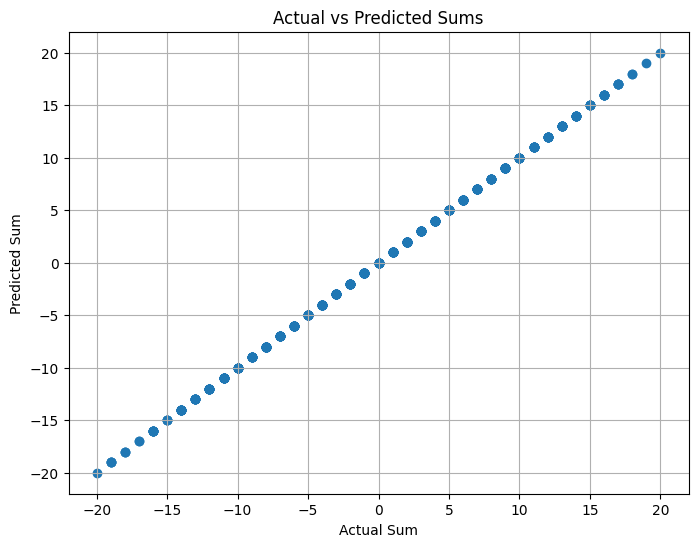

In [ ]:

actual_values = y_test_tensor.numpy().flatten()

predicted_values = (
    test_predictions.numpy().flatten()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_values,
    predicted_values
)

plt.xlabel("Actual Sum")
plt.ylabel("Predicted Sum")

plt.title("Actual vs Predicted Sums")

plt.grid(True)

plt.show()

# 12. LOSS CURVE

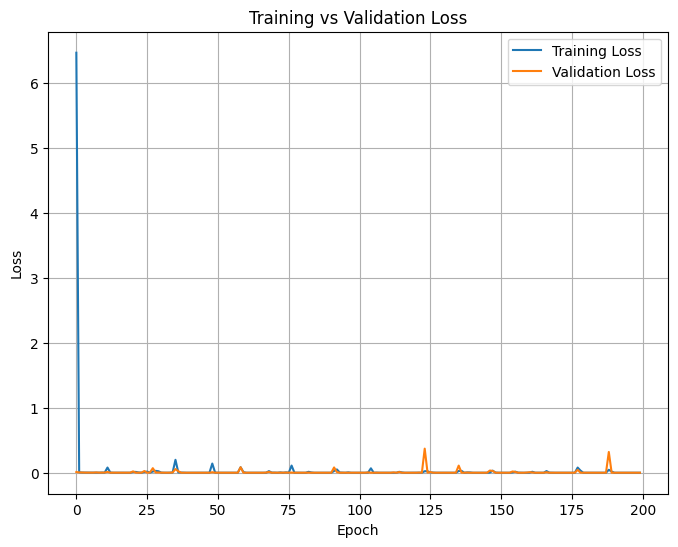

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()
